In [1]:
import sys, importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from scipy.spatial import KDTree
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [2]:
PROJECT_ROOT = Path.cwd().resolve()

while not (
    (PROJECT_ROOT / "Detection").exists()
    and (PROJECT_ROOT / "Image-Preprocessing").exists()
    and (PROJECT_ROOT / "Ground-Truth").exists()
    and (PROJECT_ROOT / "QD-Analysis").exists()
):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not find project root.")
    PROJECT_ROOT = PROJECT_ROOT.parent

DETECTION_DIR = PROJECT_ROOT / "Detection"
PREPROCESSING_DIR = PROJECT_ROOT / "Image-Preprocessing"
GROUND_TRUTH_DIR = PROJECT_ROOT / "Ground-Truth"
QD_ANALYSIS_DIR = PROJECT_ROOT / "QD-Analysis"
CLASSICAL_DIR = DETECTION_DIR / "Classical-Optimised"
CNN_DIR = DETECTION_DIR / "Binary-Unet"

for path in [PROJECT_ROOT, DETECTION_DIR, PREPROCESSING_DIR, GROUND_TRUTH_DIR, QD_ANALYSIS_DIR, CLASSICAL_DIR, CNN_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import basic_data_preprocessing as bdp
import detection_algorithms as da
import QD_analysis as qa

importlib.reload(qa)

top5_algorithms = ["U-Net", "Watershed", "Chambolle", "Otsu", "LoG"]

print("PROJECT_ROOT:", PROJECT_ROOT)

PROJECT_ROOT: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis


In [3]:
scans = {}

for scan_name in ["Scan1", "Scan2", "Scan3"]:
    scan_folder = GROUND_TRUTH_DIR / "NPY-Ground-Truth" / scan_name

    raw = np.load(scan_folder / "channel_00___0_data.npy")
    gt_mask = np.load(scan_folder / "channel_00___0_data_mask.npy").astype(bool)

    processed, _ = bdp.preprocess_afm(raw, remove_plane=True, line_flatten=True, align_rows=True, remove_2d_background=False)
    processed, _ = bdp.remove_partial_horizontal_stripes(
        processed,
        sigma_x=35,
        sigma_y_small=1.0,
        sigma_y_large=12.0,
        strength=0.75,
    )
    normalised = bdp.robust_normalise(processed).astype(np.float32)

    scans[scan_name] = {
        "raw": raw,
        "processed": processed,
        "image": normalised,
        "gt_mask": gt_mask,
        "gt_centres": qa.centres_from_binary_mask(gt_mask),
    }

print(scans["Scan1"].keys())

dict_keys(['raw', 'processed', 'image', 'gt_mask', 'gt_centres'])


In [4]:
unet_model = tf.keras.models.load_model(PROJECT_ROOT / "Detection" / "Binary-Unet" / "qd_unet_fold1.keras", compile=False)

In [5]:
import stacked_model_helper_functions as sm
import basic_data_preprocessing as bdp
import foreground_preprocessing as fp
import preprocessing_metrics as pm

import detection_algorithms as da
import detection_errors as de

import QD_analysis as qa
import feature_evaluation as fe


responses_by_scan = {}
unet_prob_by_scan = {}
unet_mask_by_scan = {}

for scan_name in ["Scan1", "Scan2", "Scan3"]:
    response_dict, unet_prob, unet_mask = sm.run_top5_detectors(
        raw=scans[scan_name]["raw"],
        processed=scans[scan_name]["processed"],
        normalised=scans[scan_name]["image"],
        unet_model=unet_model,
        unet_threshold=0.2,
    )

    responses_by_scan[scan_name] = response_dict
    unet_prob_by_scan[scan_name] = unet_prob
    unet_mask_by_scan[scan_name] = unet_mask

for scan_name in responses_by_scan:
    print(scan_name, {k: len(v) for k, v in responses_by_scan[scan_name].items()})

PROJECT_ROOT: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis
Scan1 {'LoG': 125, 'Otsu': 147, 'Chambolle': 127, 'Watershed': 139, 'U-Net': 147}
Scan2 {'LoG': 139, 'Otsu': 140, 'Chambolle': 140, 'Watershed': 145, 'U-Net': 158}
Scan3 {'LoG': 135, 'Otsu': 151, 'Chambolle': 143, 'Watershed': 193, 'U-Net': 134}


In [6]:
gt_train_tables = []

for scan_name in ["Scan1", "Scan2"]:
    qd_df = qa.extract_qd_features(scans[scan_name]["processed"], scans[scan_name]["gt_mask"]).copy()
    qd_df["scan_name"] = scan_name

    for algorithm in top5_algorithms:
        centres = responses_by_scan[scan_name][algorithm]
        detected, distance = qa.match_detections(qd_df, centres, tolerance=3.0)
        qd_df[f"{qa.safe_name(algorithm)}_after"] = detected
        qd_df[f"{qa.safe_name(algorithm)}_after_distance"] = distance

    gt_train_tables.append(qd_df)

gt_train_df = pd.concat(gt_train_tables, ignore_index=True)
display(gt_train_df.head())
print([c for c in gt_train_df.columns if c.endswith("_after")])

,qd_id,cy,cx,height,area,radius,local_contrast,local_background_std,local_background_mad,nearest_qd_distance,...,unet_after,unet_after_distance,watershed_after,watershed_after_distance,chambolle_after,chambolle_after_distance,otsu_after,otsu_after_distance,log_after,log_after_distance
0,1,0.857143,375.380952,1.383941e-09,21.0,2.585441,8.069006e-10,1.829297e-10,1.701204e-10,35.214160,...,True,0.224619,False,NaN,True,0.937986,True,0.937986,True,0.937986
1,2,4.388889,47.833333,1.257406e-09,36.0,3.385138,7.607264e-10,2.292948e-10,1.342278e-10,23.851353,...,True,0.493202,True,0.633431,True,0.633431,True,0.633431,True,0.633431
2,3,6.000000,135.000000,6.727854e-10,45.0,3.784699,5.994098e-11,4.352281e-10,4.285966e-10,22.192761,...,False,NaN,False,NaN,False,NaN,False,NaN,False,NaN
3,4,13.900000,243.585714,1.815759e-09,70.0,4.720349,1.257243e-09,1.658430e-10,1.647897e-10,29.745801,...,True,0.198418,True,1.791704,True,1.791704,True,1.791704,True,1.791704
4,5,13.276596,492.382979,1.679394e-09,47.0,3.867889,9.478566e-10,3.097020e-10,2.681154e-10,20.145476,...,True,0.158304,True,2.060207,True,1.410367,True,1.410367,True,1.410367


['unet_after', 'watershed_after', 'chambolle_after', 'otsu_after', 'log_after']


In [7]:
rescue_matrix = qa.build_rescue_matrix(gt_train_df, top5_algorithms)
display(rescue_matrix)

,U-Net,Watershed,Chambolle,Otsu,LoG
U-Net,0.000,0.870370,0.837209,0.84375,0.829268
Watershed,0.125,0.000000,0.534884,0.53125,0.512195
Chambolle,0.125,0.629630,0.000000,0.18750,0.097561
Otsu,0.375,0.722222,0.395349,0.00000,0.439024
LoG,0.125,0.629630,0.139535,0.28125,0.000000


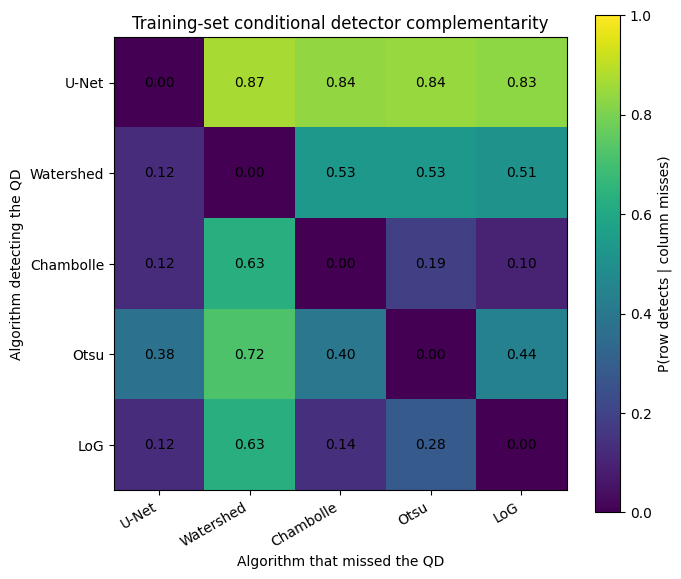

In [8]:
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(rescue_matrix, vmin=0, vmax=1, cmap="viridis")
ax.set_xticks(np.arange(len(top5_algorithms)))
ax.set_xticklabels(top5_algorithms, rotation=30, ha="right")
ax.set_yticks(np.arange(len(top5_algorithms)))
ax.set_yticklabels(top5_algorithms)

for i in range(len(top5_algorithms)):
    for j in range(len(top5_algorithms)):
        value = rescue_matrix.iloc[i, j]
        if np.isfinite(value):
            ax.text(j, i, f"{value:.2f}", ha="center", va="center")

ax.set_xlabel("Algorithm that missed the QD")
ax.set_ylabel("Algorithm detecting the QD")
ax.set_title("Training-set conditional detector complementarity")
fig.colorbar(im, ax=ax, label="P(row detects | column misses)")
plt.tight_layout()
plt.show()

In [9]:
train_candidate_tables = []

def add_complementarity_features(candidate_df, rescue_matrix):
    candidate_df = candidate_df.copy()

    for missed_by in top5_algorithms:
        score = np.zeros(len(candidate_df), dtype=float)

        for detector in top5_algorithms:
            if detector == missed_by:
                continue
            score += candidate_df[qa.safe_name(detector)].to_numpy(dtype=float) * rescue_matrix.loc[detector, missed_by]

        candidate_df[f"rescue_{qa.safe_name(missed_by)}"] = score

    return candidate_df


for scan_name in ["Scan1", "Scan2"]:
    candidate_df = sm.build_candidate_table(
        scan_name=scan_name,
        detector_centres_dict=responses_by_scan[scan_name],
        gt_centres=scans[scan_name]["gt_centres"],
        tolerance=3.0,
        merge_radius=3.0,
    )

    candidate_df = add_complementarity_features(candidate_df, rescue_matrix)
    train_candidate_tables.append(candidate_df)

train_candidates = pd.concat(train_candidate_tables, ignore_index=True)
display(train_candidates.head())
print(train_candidates.shape)

,scan_name,cy,cx,unet,unet_distance,watershed,watershed_distance,chambolle,chambolle_distance,otsu,...,log,log_distance,is_true_qd,matched_gt_idx,gt_distance,rescue_unet,rescue_watershed,rescue_chambolle,rescue_otsu,rescue_log
0,Scan1,0.166667,375.125000,1,0.625000,0,36.965661,1,0.208333,1,...,1,0.208333,1,0,0.736389,0.625,2.851852,1.372093,1.31250,1.365854
1,Scan1,4.645833,48.319444,1,0.463408,1,0.476947,1,0.476947,1,...,1,0.476947,1,1,0.549840,0.750,2.851852,1.906977,1.84375,1.878049
2,Scan1,2.875000,136.375000,1,0.951972,1,0.395285,0,23.289617,1,...,0,23.289617,0,-1,NaN,0.500,1.592593,1.767442,1.37500,1.780488
3,Scan1,14.817391,244.730435,1,1.302375,1,0.325594,1,0.325594,1,...,1,0.325594,1,3,1.466967,0.750,2.851852,1.906977,1.84375,1.878049
4,Scan1,12.824490,491.869388,1,0.562881,1,2.284577,1,0.886927,1,...,1,0.886927,1,4,0.684233,0.750,2.851852,1.906977,1.84375,1.878049


(337, 21)


In [10]:
base_features = [qa.safe_name(a) for a in top5_algorithms]
rescue_features = [f"rescue_{qa.safe_name(a)}" for a in top5_algorithms]
feature_columns = base_features + rescue_features

X_train = train_candidates[feature_columns]
y_train = train_candidates["is_true_qd"].astype(int)

rf_meta = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_leaf=2,
    class_weight="balanced",
    n_jobs=-1,
    random_state=50,
)

rf_meta.fit(X_train, y_train)

print("Training positives:", y_train.sum(), "out of", len(y_train))
print("Feature columns:", feature_columns)

Training positives: 263 out of 337
Feature columns: ['unet', 'watershed', 'chambolle', 'otsu', 'log', 'rescue_unet', 'rescue_watershed', 'rescue_chambolle', 'rescue_otsu', 'rescue_log']


In [11]:
scan3_candidates = sm.build_candidate_table(
    scan_name="Scan3",
    detector_centres_dict=responses_by_scan["Scan3"],
    gt_centres=scans["Scan3"]["gt_centres"],
    tolerance=4.0,
    merge_radius=4.0,
)

scan3_candidates = add_complementarity_features(scan3_candidates, rescue_matrix)

X_test = scan3_candidates[feature_columns]
y_test = scan3_candidates["is_true_qd"].astype(int)

scan3_candidates["rf_probability"] = rf_meta.predict_proba(X_test)[:, 1]
scan3_candidates["rf_pred"] = (scan3_candidates["rf_probability"] >= 0.5).astype(int)

display(scan3_candidates.head())

,scan_name,cy,cx,unet,unet_distance,watershed,watershed_distance,chambolle,chambolle_distance,otsu,...,is_true_qd,matched_gt_idx,gt_distance,rescue_unet,rescue_watershed,rescue_chambolle,rescue_otsu,rescue_log,rf_probability,rf_pred
0,Scan3,1.303571,294.982143,1,0.912289,0,33.174640,1,0.304096,1,...,1,1,1.560361,0.625,2.851852,1.372093,1.31250,1.365854,0.553114,1
1,Scan3,9.995652,365.847826,1,0.608944,1,0.152236,1,0.152236,1,...,1,2,0.442625,0.750,2.851852,1.906977,1.84375,1.878049,0.939382,1
2,Scan3,10.506667,459.713333,1,0.984322,1,0.874960,1,0.570575,1,...,1,3,0.809640,0.750,2.851852,1.906977,1.84375,1.878049,0.939382,1
3,Scan3,17.266667,329.145833,1,1.215753,1,0.303938,1,0.303938,1,...,1,5,1.615961,0.750,2.851852,1.906977,1.84375,1.878049,0.939382,1
4,Scan3,23.108974,439.096154,1,1.585939,1,2.111165,1,0.910392,1,...,1,6,1.915211,0.750,2.851852,1.906977,1.84375,1.878049,0.939382,1


In [12]:
precision = precision_score(y_test, scan3_candidates["rf_pred"], zero_division=0)
recall = recall_score(y_test, scan3_candidates["rf_pred"], zero_division=0)
f1 = f1_score(y_test, scan3_candidates["rf_pred"], zero_division=0)

print(f"Scan3 meta-model precision = {precision:.3f}")
print(f"Scan3 meta-model recall    = {recall:.3f}")
print(f"Scan3 meta-model F1        = {f1:.3f}")

print("\nConfusion matrix:")
print(confusion_matrix(y_test, scan3_candidates["rf_pred"]))

print("\nClassification report:")
print(classification_report(y_test, scan3_candidates["rf_pred"], zero_division=0))

Scan3 meta-model precision = 0.920
Scan3 meta-model recall    = 0.806
Scan3 meta-model F1        = 0.860

Confusion matrix:
[[ 71   9]
 [ 25 104]]

Classification report:
              precision    recall  f1-score   support

           0       0.74      0.89      0.81        80
           1       0.92      0.81      0.86       129

    accuracy                           0.84       209
   macro avg       0.83      0.85      0.83       209
weighted avg       0.85      0.84      0.84       209



,feature,importance
6,rescue_watershed,0.239033
9,rescue_log,0.212477
7,rescue_chambolle,0.202181
8,rescue_otsu,0.160854
5,rescue_unet,0.108917
4,log,0.036536
2,chambolle,0.024387
1,watershed,0.007105
3,otsu,0.004403
0,unet,0.004108


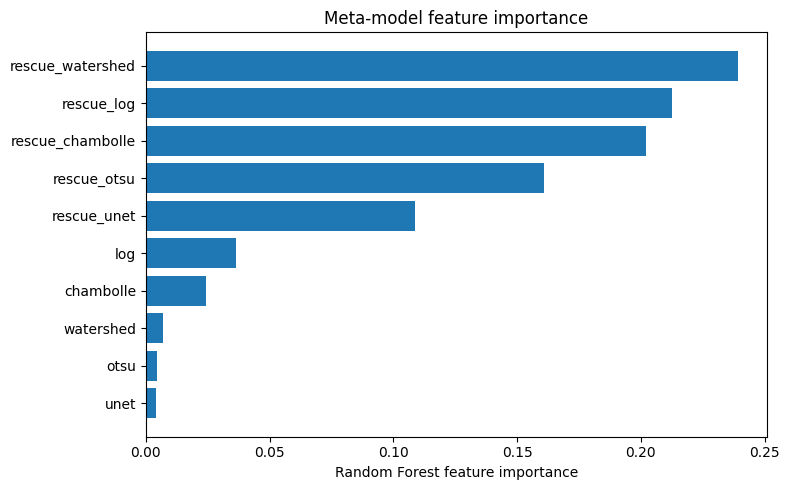

In [13]:
importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf_meta.feature_importances_,
}).sort_values("importance", ascending=False)

display(importance_df)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance_df["feature"], importance_df["importance"])
ax.invert_yaxis()
ax.set_xlabel("Random Forest feature importance")
ax.set_title("Meta-model feature importance")
plt.tight_layout()
plt.show()

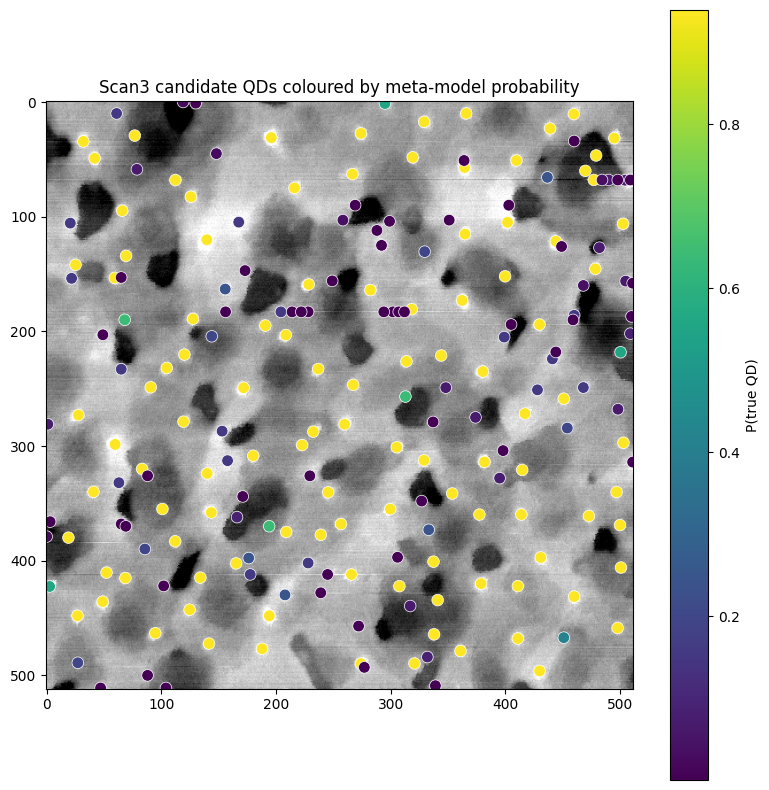

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))

img = scans["Scan3"]["image"]
vmin, vmax = np.nanpercentile(img, [1, 99])

ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)

scatter = ax.scatter(
    scan3_candidates["cx"],
    scan3_candidates["cy"],
    c=scan3_candidates["rf_probability"],
    cmap="viridis",
    s=70,
    edgecolors="white",
    linewidths=0.5,
)

ax.set_title("Scan3 candidate QDs coloured by meta-model probability")
fig.colorbar(scatter, ax=ax, label="P(true QD)")
plt.tight_layout()
plt.show()

In [15]:
rows = []

for algorithm in top5_algorithms:
    safe = qa.safe_name(algorithm)
    pred = scan3_candidates[safe].astype(int)

    rows.append({
        "model": algorithm,
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
    })

rows.append({
    "model": "RF-meta",
    "precision": precision_score(y_test, scan3_candidates["rf_pred"], zero_division=0),
    "recall": recall_score(y_test, scan3_candidates["rf_pred"], zero_division=0),
    "f1": f1_score(y_test, scan3_candidates["rf_pred"], zero_division=0),
})

comparison_df = pd.DataFrame(rows).sort_values("f1", ascending=False)
display(comparison_df)

,model,precision,recall,f1
0,U-Net,0.879699,0.906977,0.893130
5,RF-meta,0.920354,0.806202,0.859504
4,LoG,0.829630,0.868217,0.848485
3,Otsu,0.781457,0.914729,0.842857
2,Chambolle,0.797203,0.883721,0.838235
1,Watershed,0.645161,0.930233,0.761905


Filtering by threshold

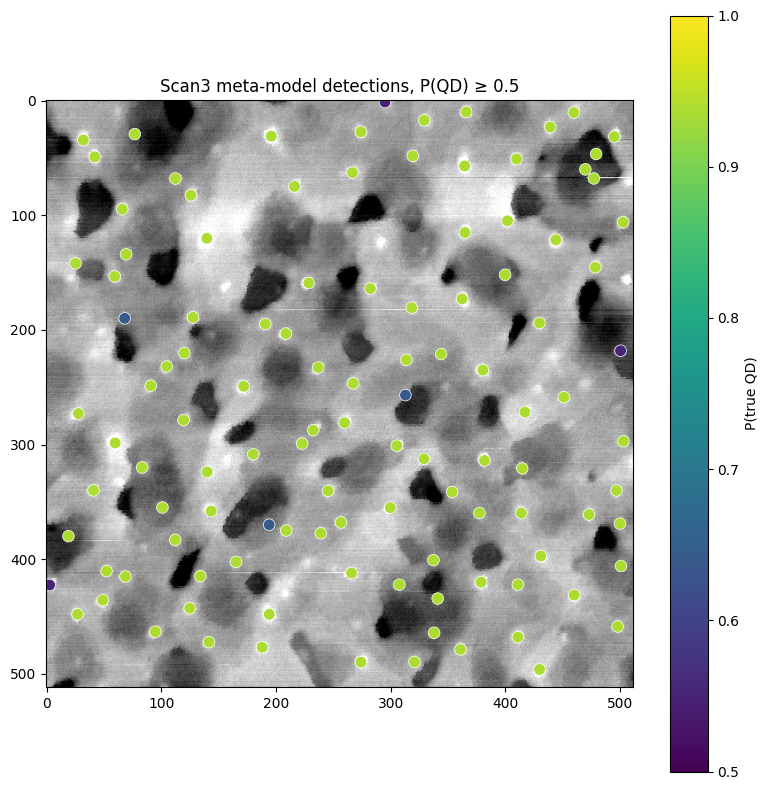

In [16]:
threshold = 0.5

selected_candidates = scan3_candidates[
    scan3_candidates["rf_probability"] >= threshold
].copy()

fig, ax = plt.subplots(figsize=(8, 8))

img = scans["Scan3"]["image"]
vmin, vmax = np.nanpercentile(img, [1, 99])

ax.imshow(img, cmap="gray", vmin=vmin, vmax=vmax)

scatter = ax.scatter(
    selected_candidates["cx"],
    selected_candidates["cy"],
    c=selected_candidates["rf_probability"],
    cmap="viridis",
    vmin=threshold,
    vmax=1,
    s=70,
    edgecolors="white",
    linewidths=0.5,
)

ax.set_title(f"Scan3 meta-model detections, P(QD) ≥ {threshold}")
fig.colorbar(scatter, ax=ax, label="P(true QD)")

plt.tight_layout()
plt.show()

In [17]:
predicted_centres = selected_candidates[["cy", "cx"]].to_numpy()
gt_centres = scans["Scan3"]["gt_centres"]

distances = cdist(gt_centres, predicted_centres)

gt_idx, pred_idx = linear_sum_assignment(distances)

matched = distances[gt_idx, pred_idx] <= 4.0

tp = matched.sum()
fp = len(predicted_centres) - tp
fn = len(gt_centres) - tp

precision = tp / (tp + fp) if tp + fp else 0
recall = tp / (tp + fn) if tp + fn else 0
f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0

print(f"Threshold: {threshold:.2f}")
print(f"Predicted QDs: {len(predicted_centres)}")
print(f"TP: {tp}, FP: {fp}, FN: {fn}")
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"F1: {f1:.3f}")

Threshold: 0.50
Predicted QDs: 113
TP: 104, FP: 9, FN: 31
Precision: 0.920
Recall: 0.770
F1: 0.839


In [18]:
rows = []

for threshold in np.arange(0.1, 1.0, 0.05):
    selected = scan3_candidates[scan3_candidates["rf_probability"] >= threshold]
    pred = selected[["cy", "cx"]].to_numpy()
    gt = scans["Scan3"]["gt_centres"]

    if len(pred) == 0:
        tp, fp, fn = 0, 0, len(gt)
    else:
        distances = cdist(gt, pred)
        gt_idx, pred_idx = linear_sum_assignment(distances)
        tp = np.sum(distances[gt_idx, pred_idx] <= 3.0)
        fp = len(pred) - tp
        fn = len(gt) - tp

    precision = tp / (tp + fp) if tp + fp else 0
    recall = tp / (tp + fn) if tp + fn else 0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0

    rows.append({
        "threshold": threshold,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "predicted_qds": len(pred),
    })

threshold_results = pd.DataFrame(rows)
display(threshold_results)

best = threshold_results.loc[threshold_results["f1"].idxmax()]
print("\nBest threshold:")
display(best)

,threshold,precision,recall,f1,predicted_qds
0,0.10,0.757143,0.785185,0.770909,140
1,0.15,0.757143,0.785185,0.770909,140
2,0.20,0.831933,0.733333,0.779528,119
3,0.25,0.868421,0.733333,0.795181,114
4,0.30,0.868421,0.733333,0.795181,114
5,0.35,0.868421,0.733333,0.795181,114
6,0.40,0.868421,0.733333,0.795181,114
7,0.45,0.867257,0.725926,0.790323,113
8,0.50,0.867257,0.725926,0.790323,113
9,0.55,0.867257,0.725926,0.790323,113



Best threshold:


threshold          0.250000
precision          0.868421
recall             0.733333
f1                 0.795181
predicted_qds    114.000000
Name: 3, dtype: float64

# Increasing the dataset

In [19]:
from pathlib import Path
import numpy as np
import pandas as pd
importlib.reload(sm)

GT_ROOT = GROUND_TRUTH_DIR / "NPY-Ground-Truth"

scan_names = sorted([
    p.name for p in GT_ROOT.iterdir()
    if p.is_dir() and p.name != "Scan3"
])

print("Training scans:", scan_names)
print("Held-out test scan: Scan3")

def load_scan(scan_name):
    folder = GT_ROOT / scan_name

    raw = np.load(folder / "channel_00___0_data.npy")
    gt_mask = np.load(folder / "channel_00___0_data_mask.npy").astype(bool)

    processed, _ = bdp.preprocess_afm(
        raw,
        remove_plane=True,
        line_flatten=True,
        align_rows=True,
        remove_2d_background=False,
    )

    normalised = bdp.robust_normalise(processed).astype(np.float32)

    return {
        "raw": raw,
        "processed": processed,
        "normalised": normalised,
        "gt_mask": gt_mask,
        "gt_centres": qa.centres_from_binary_mask(gt_mask),
    }

all_scans = {
    name: load_scan(name)
    for name in scan_names + ["Scan3"]
}

PROJECT_ROOT: /Users/polinabobrova/Desktop/GaN Quantum Dot Analysis
Training scans: ['SPM_1nm_QD_AFMs_AIX6468_along_curved_edge_1um_100pN_18gain.0_00000', 'SPM_1nm_QD_AFMs_AIX6468_along_the_flat_edge_1um_100pN_18gain.0_00000', 'SPM_2nm_QD_AFMs_AIX6461_along_the_flat_edge_1um_200pN_15gain_2um_zrange.0_00000', 'SPM_2nm_QD_AFMs_AIX6461_in_the_centre_1um_200pN_10gain_2um_zrange.0_00000', 'SPM_3nm_QD_AFMs_AIX6470_along_curved_edge_1um_100pN_18gain.0_00000', 'SPM_3nm_QD_AFMs_AIX6470_along_curved_edge_1um_100pN_18gain.0_00001', 'SPM_Uncapped_InGaN_QDs_different_miscut_AIX7104A_CTM0.35°_500nm_3', 'SPM_Uncapped_InGaN_QDs_different_miscut_AIX7104B_CTM0.80°_500nm_4', 'SPM_Uncapped_InGaN_QDs_different_miscut_AIX7104C_CTA0.25°_500nm_1', 'SPM_Uncapped_InGaN_QDs_different_miscut_AIX7104D_CTA0.50°_500nm_1', 'SPM_Uncapped_InGaN_QDs_different_miscut_AIX7104E_CTA0.75°_500nm_1', 'SPM_Uncapped_InGaN_QDs_different_miscut_AIX7104F_CTA1.00°_500nm_5', 'Scan1', 'Scan2']
Held-out test scan: Scan3


In [20]:
augmented_scans = {}

for scan_name in scan_names:
    scan = all_scans[scan_name]

    variants = sm.augment_scan(
        scan["raw"],
        scan["processed"],
        scan["normalised"],
        scan["gt_mask"],
    )

    for augmentation_name, data in variants.items():
        key = f"{scan_name}_{augmentation_name}"
        data["original_scan"] = scan_name
        data["augmentation"] = augmentation_name

        augmented_scans[key] = data

print("Total training variants:", len(augmented_scans))

Total training variants: 84


In [21]:
responses_by_scan = {}

for key, scan in augmented_scans.items():
    detector_centres, unet_prob, unet_mask = sm.run_top5_detectors(
        raw=scan["raw"],
        processed=scan["processed"],
        normalised=scan["normalised"],
        unet_model=unet_model,
        unet_threshold=0.5,
    )

    responses_by_scan[key] = detector_centres

    print(key, {algorithm: len(centres) for algorithm, centres in detector_centres.items()})

SPM_1nm_QD_AFMs_AIX6468_along_curved_edge_1um_100pN_18gain.0_00000_original {'LoG': 584, 'Otsu': 616, 'Chambolle': 611, 'Watershed': 533, 'U-Net': 650}
SPM_1nm_QD_AFMs_AIX6468_along_curved_edge_1um_100pN_18gain.0_00000_flip_h {'LoG': 584, 'Otsu': 616, 'Chambolle': 611, 'Watershed': 534, 'U-Net': 650}
SPM_1nm_QD_AFMs_AIX6468_along_curved_edge_1um_100pN_18gain.0_00000_flip_v {'LoG': 584, 'Otsu': 616, 'Chambolle': 614, 'Watershed': 532, 'U-Net': 648}
SPM_1nm_QD_AFMs_AIX6468_along_curved_edge_1um_100pN_18gain.0_00000_rot90 {'LoG': 584, 'Otsu': 616, 'Chambolle': 611, 'Watershed': 532, 'U-Net': 646}
SPM_1nm_QD_AFMs_AIX6468_along_curved_edge_1um_100pN_18gain.0_00000_rot180 {'LoG': 584, 'Otsu': 616, 'Chambolle': 611, 'Watershed': 534, 'U-Net': 650}
SPM_1nm_QD_AFMs_AIX6468_along_curved_edge_1um_100pN_18gain.0_00000_rot270 {'LoG': 584, 'Otsu': 616, 'Chambolle': 614, 'Watershed': 531, 'U-Net': 650}
SPM_1nm_QD_AFMs_AIX6468_along_the_flat_edge_1um_100pN_18gain.0_00000_original {'LoG': 604, 'Otsu': 

In [22]:
gt_tables = {}

for key, scan in augmented_scans.items():
    qd_df = qa.extract_qd_features(
        scan["processed"],
        scan["gt_mask"],
    )

    qd_df["scan_key"] = key
    qd_df["original_scan"] = scan["original_scan"]

    for algorithm in top5_algorithms:
        centres = responses_by_scan[key][algorithm]

        detected, distance = qa.match_detections(
            qd_df,
            centres,
            tolerance=5.0,
        )

        safe = qa.safe_name(algorithm)

        qd_df[f"{safe}_after"] = detected
        qd_df[f"{safe}_after_distance"] = distance

    gt_tables[key] = qd_df

In [23]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

In [24]:
original_scans = sorted(set(
    scan["original_scan"]
    for scan in augmented_scans.values()
))

print(original_scans)

['SPM_1nm_QD_AFMs_AIX6468_along_curved_edge_1um_100pN_18gain.0_00000', 'SPM_1nm_QD_AFMs_AIX6468_along_the_flat_edge_1um_100pN_18gain.0_00000', 'SPM_2nm_QD_AFMs_AIX6461_along_the_flat_edge_1um_200pN_15gain_2um_zrange.0_00000', 'SPM_2nm_QD_AFMs_AIX6461_in_the_centre_1um_200pN_10gain_2um_zrange.0_00000', 'SPM_3nm_QD_AFMs_AIX6470_along_curved_edge_1um_100pN_18gain.0_00000', 'SPM_3nm_QD_AFMs_AIX6470_along_curved_edge_1um_100pN_18gain.0_00001', 'SPM_Uncapped_InGaN_QDs_different_miscut_AIX7104A_CTM0.35°_500nm_3', 'SPM_Uncapped_InGaN_QDs_different_miscut_AIX7104B_CTM0.80°_500nm_4', 'SPM_Uncapped_InGaN_QDs_different_miscut_AIX7104C_CTA0.25°_500nm_1', 'SPM_Uncapped_InGaN_QDs_different_miscut_AIX7104D_CTA0.50°_500nm_1', 'SPM_Uncapped_InGaN_QDs_different_miscut_AIX7104E_CTA0.75°_500nm_1', 'SPM_Uncapped_InGaN_QDs_different_miscut_AIX7104F_CTA1.00°_500nm_5', 'Scan1', 'Scan2']


In [25]:
n_splits = min(5, len(original_scans))
group_kfold = GroupKFold(n_splits=n_splits)

I've had to define some of the functions here because I have forgotten how to use dynamic memory. And there was lots of dependence of the functions on global variables here.

In [33]:
def build_meta_dataset(keys, rescue_matrix):
    tables = []

    for key in keys:
        scan = augmented_scans[key]

        candidate_df = sm.build_candidate_table(
            scan_name=key,
            detector_centres_dict=responses_by_scan[key],
            gt_centres=scan["gt_centres"],
            tolerance=5.0,
            merge_radius=3.0,
        )

        candidate_df["original_scan"] = scan["original_scan"]
        candidate_df = add_complementarity_features(candidate_df, rescue_matrix)

        tables.append(candidate_df)

    return pd.concat(tables, ignore_index=True)

In [34]:
cv_rows = []

scan_array = np.array(original_scans)

for fold, (train_idx, val_idx) in enumerate(
    group_kfold.split(scan_array, groups=scan_array),
    start=1,
):
    train_scan_names = set(scan_array[train_idx])
    val_scan_names = set(scan_array[val_idx])

    train_keys = [
        key for key, scan in augmented_scans.items()
        if scan["original_scan"] in train_scan_names
    ]

    val_keys = [
        key for key, scan in augmented_scans.items()
        if scan["original_scan"] in val_scan_names
    ]

    # Complementarity calculated ONLY from training scans
    fold_gt_train = pd.concat(
        [gt_tables[key] for key in train_keys],
        ignore_index=True,
    )

    fold_rescue_matrix = qa.build_rescue_matrix(
        fold_gt_train,
        top5_algorithms,
    )

    train_candidates = build_meta_dataset(
        train_keys,
        fold_rescue_matrix,
    )

    val_candidates = build_meta_dataset(
        val_keys,
        fold_rescue_matrix,
    )

    base_features = [
        qa.safe_name(a)
        for a in top5_algorithms
    ]

    rescue_features = [
        f"rescue_{qa.safe_name(a)}"
        for a in top5_algorithms
    ]

    feature_columns = base_features + rescue_features

    X_train = train_candidates[feature_columns]
    y_train = train_candidates["is_true_qd"].astype(int)

    X_val = val_candidates[feature_columns]
    y_val = val_candidates["is_true_qd"].astype(int)

    model_fold = RandomForestClassifier(
        n_estimators=500,
        max_depth=8,
        min_samples_leaf=3,
        class_weight="balanced",
        n_jobs=-1,
        random_state=42 + fold,
    )

    model_fold.fit(X_train, y_train)

    probability = model_fold.predict_proba(X_val)[:, 1]
    prediction = probability >= 0.5

    precision = precision_score(
        y_val,
        prediction,
        zero_division=0,
    )

    recall = recall_score(
        y_val,
        prediction,
        zero_division=0,
    )

    f1 = f1_score(
        y_val,
        prediction,
        zero_division=0,
    )

    cv_rows.append({
        "fold": fold,
        "validation_scans": ", ".join(sorted(val_scan_names)),
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "n_train_candidates": len(train_candidates),
        "n_val_candidates": len(val_candidates),
    })

cv_results = pd.DataFrame(cv_rows)

display(cv_results)

,fold,validation_scans,precision,recall,f1,n_train_candidates,n_val_candidates
0,1,SPM_2nm_QD_AFMs_AIX6461_in_the_centre_1um_200p...,0.937669,0.887559,0.911926,36681,6213
1,2,SPM_2nm_QD_AFMs_AIX6461_along_the_flat_edge_1u...,0.883498,0.911795,0.897423,32855,10039
2,3,SPM_1nm_QD_AFMs_AIX6468_along_the_flat_edge_1u...,0.904087,0.922731,0.913314,31434,11460
3,4,SPM_1nm_QD_AFMs_AIX6468_along_curved_edge_1um_...,0.928850,0.916346,0.922556,33331,9563
4,5,SPM_3nm_QD_AFMs_AIX6470_along_curved_edge_1um_...,0.844403,0.845194,0.844798,37275,5619


In [ ]:
print("Mean CV F1:", cv_results["f1"].mean())

print("F1 std:", cv_results["f1"].std())

Mean CV F1: 0.8980033438688515
F1 std: 0.031073368384752824


In [ ]:
all_training_gt = pd.concat(list(gt_tables.values()), ignore_index=True)
final_rescue_matrix = qa.build_rescue_matrix(all_training_gt, top5_algorithms,)
display(final_rescue_matrix)

,U-Net,Watershed,Chambolle,Otsu,LoG
U-Net,0.000000,0.848292,0.848166,0.867124,0.857042
Watershed,0.458678,0.000000,0.650936,0.707063,0.619014
Chambolle,0.388430,0.605964,0.000000,0.319106,0.232629
Otsu,0.459711,0.666184,0.312644,0.000000,0.390141
LoG,0.370868,0.530110,0.161580,0.339939,0.000000


In [37]:
all_training_keys = list(augmented_scans.keys())

final_train_candidates = build_meta_dataset(
    all_training_keys,
    final_rescue_matrix,
)

base_features = [qa.safe_name(a) for a in top5_algorithms]
rescue_features = [f"rescue_{qa.safe_name(a)}" for a in top5_algorithms]

feature_columns = base_features + rescue_features

X_train = final_train_candidates[feature_columns]
y_train = final_train_candidates["is_true_qd"].astype(int)

In [38]:
final_rf = RandomForestClassifier(
    n_estimators=1000,
    max_depth=8,
    min_samples_leaf=3,
    class_weight="balanced",
    n_jobs=-1,
    random_state=42,
)

final_rf.fit(X_train, y_train)

,n_estimators,1000
,criterion,'gini'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,3
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
scan3 = all_scans["Scan3"]

scan3_responses, scan3_unet_prob, scan3_unet_mask = sm.run_top5_detectors(
    raw=scan3["raw"],
    processed=scan3["processed"],
    normalised=scan3["normalised"],
    unet_model=unet_model,
    unet_threshold=0.5,
)

scan3_candidates = sm.build_candidate_table(
    scan_name="Scan3",
    detector_centres_dict=scan3_responses,
    gt_centres=scan3["gt_centres"],
    tolerance=5.0,
    merge_radius=3.0,
)

scan3_candidates = add_complementarity_features(
    scan3_candidates,
    final_rescue_matrix,
)

scan3_candidates["rf_probability"] = final_rf.predict_proba(scan3_candidates[feature_columns])[:, 1]

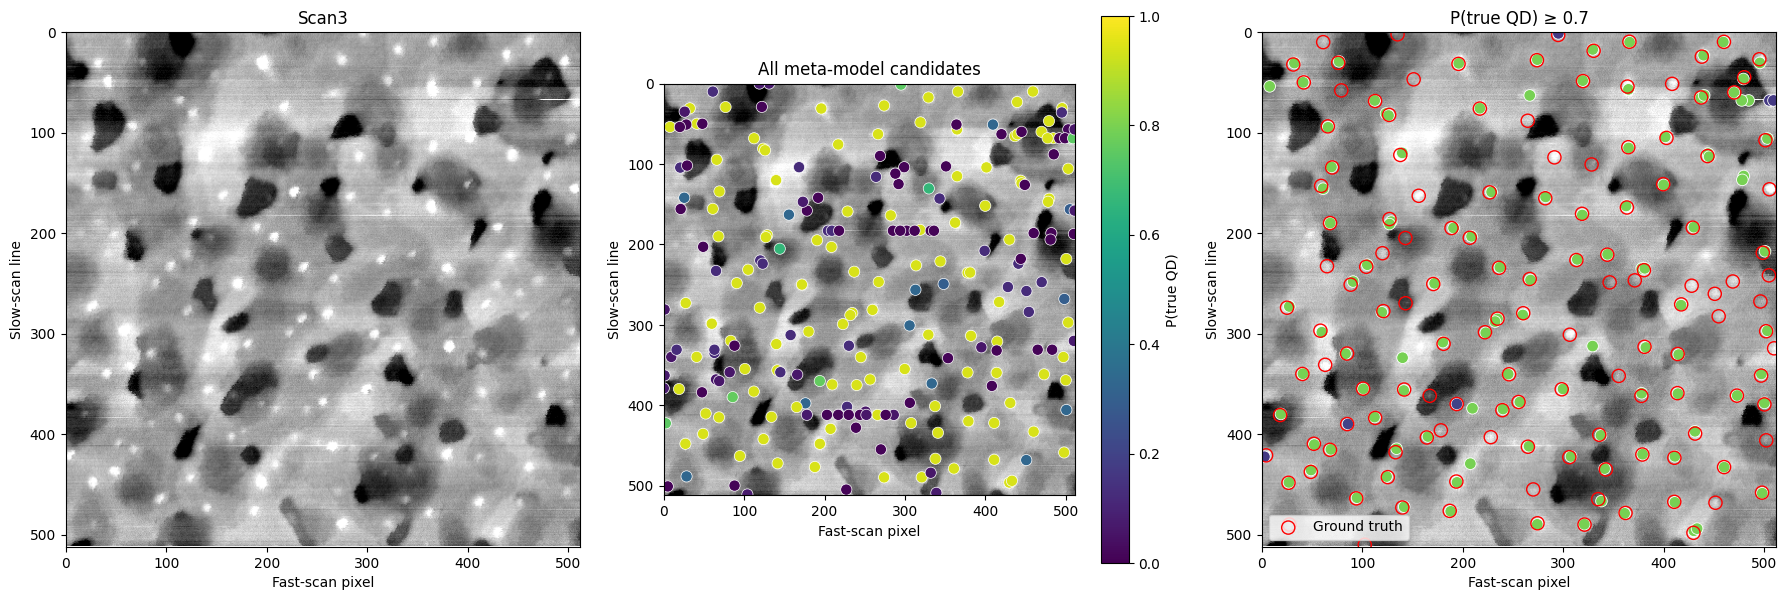

In [44]:
threshold = 0.7

selected_candidates = scan3_candidates[
    scan3_candidates["rf_probability"] >= threshold
].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

vmin, vmax = np.nanpercentile(scan3["normalised"], [1, 99])

axes[0].imshow(scan3["normalised"], cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("Scan3")

scatter = axes[1].scatter(
    scan3_candidates["cx"],
    scan3_candidates["cy"],
    c=scan3_candidates["rf_probability"],
    cmap="viridis",
    vmin=0,
    vmax=1,
    s=65,
    edgecolors="white",
    linewidths=0.5,
)

axes[1].imshow(scan3["normalised"], cmap="gray", vmin=vmin, vmax=vmax)
axes[1].set_title("All meta-model candidates")

axes[2].imshow(scan3["normalised"], cmap="gray", vmin=vmin, vmax=vmax)

axes[2].scatter(
    selected_candidates["cx"],
    selected_candidates["cy"],
    c=selected_candidates["rf_probability"],
    cmap="viridis",
    vmin=threshold,
    vmax=1,
    s=70,
    edgecolors="white",
    linewidths=0.6,
)

axes[2].scatter(
    scan3["gt_centres"][:, 1],
    scan3["gt_centres"][:, 0],
    facecolors="none",
    edgecolors="red",
    s=90,
    linewidths=1,
    label="Ground truth",
)

axes[2].set_title(f"P(true QD) ≥ {threshold}")
axes[2].legend()

for ax in axes:
    ax.set_xlim(0, scan3["normalised"].shape[1])
    ax.set_ylim(scan3["normalised"].shape[0], 0)
    ax.set_xlabel("Fast-scan pixel")
    ax.set_ylabel("Slow-scan line")

fig.colorbar(scatter, ax=axes[1], label="P(true QD)")

plt.tight_layout()
plt.show()